In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [2]:
#load data
df=pd.read_excel(r"C:\Users\aradh.LAPTOP-ASRN02G2\Downloads\Dataset.xlsx")
df.head()

,Date,Nifty Energy Price,NTPC Price,Tata Power Price,Adani Green Price
0,02/28/2025,30018.15,311.45,339.2,774.40
1,02/27/2025,30659.25,315.70,343.3,811.75
2,02/25/2025,31018.30,318.70,351.5,840.65
3,02/24/2025,31240.80,320.10,354.6,836.05
4,02/21/2025,31592.00,326.25,357.2,849.35


In [3]:
#data cleaning
missing_data=df.isnull().sum()
print(missing_data)

Date                  0
Nifty Energy Price    0
NTPC Price            0
Tata Power Price      0
Adani Green Price     0
dtype: int64


In [4]:
df.shape

(248, 5)

In [5]:
#Data information
df.info

<bound method DataFrame.info of                     Date  Nifty Energy Price  NTPC Price  Tata Power Price  \
0             02/28/2025            30018.15      311.45            339.20   
1             02/27/2025            30659.25      315.70            343.30   
2             02/25/2025            31018.30      318.70            351.50   
3             02/24/2025            31240.80      320.10            354.60   
4             02/21/2025            31592.00      326.25            357.20   
..                   ...                 ...         ...               ...   
243  2024-07-03 00:00:00            40301.80      352.20            425.25   
244  2024-06-03 00:00:00            40451.50      351.95            394.95   
245  2024-05-03 00:00:00            40646.10      358.25            396.15   
246  2024-04-03 00:00:00            40466.60      353.85            391.75   
247  2024-02-03 00:00:00            39753.55      341.75            379.15   

     Adani Green Price  
0     

In [6]:
#descriptive analysis
df.describe()

,Nifty Energy Price,NTPC Price,Tata Power Price,Adani Green Price
count,248.000000,248.000000,248.000000,248.000000
mean,39102.721169,367.813306,417.625202,1586.665121
std,3603.682610,35.762075,33.133720,371.718389
min,30018.150000,298.200000,337.150000,774.400000
25%,37041.900000,339.387500,399.262500,1192.962500
50%,39784.200000,365.225000,428.025000,1774.225000
75%,41867.462500,400.875000,439.750000,1855.437500
max,44954.450000,443.200000,485.500000,2070.550000


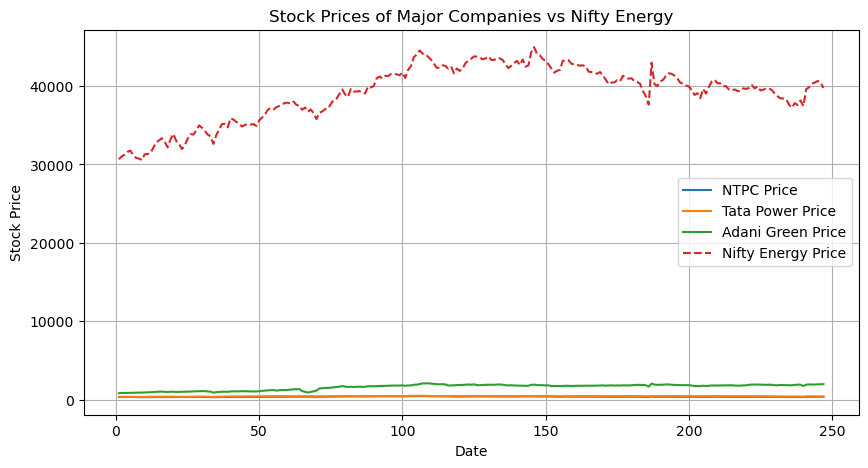

In [47]:
# Plot the stock prices over time
plt.figure(figsize=(10,5))
plt.plot(df.index, df['NTPC Price'], label='NTPC Price')
plt.plot(df.index, df['Tata Power Price'], label='Tata Power Price')
plt.plot(df.index, df['Adani Green Price'], label='Adani Green Price')
plt.plot(df.index, df['Nifty Energy Price'], label='Nifty Energy Price', linestyle='--')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Prices of Major Companies vs Nifty Energy')
plt.grid()
plt.show()

In [8]:
#Interpretation
#This graph displayThis graph displays the Nifty Energy index combined with the stock values of NTPC, TATA POWER, and ADANI GREEN .  The Nifty Energy (red dashed line), which represents overall market performance, is significantly higher.  Bank prices have less volatility and are more steady.  This implies that while individual companies have an impact on the index, the index itself reflects broader market movements. This graph displays the Nifty Energy index combined with the stock values of NTPC, TATA POWER, and ADANI GREEN .  The Nifty Energy (red dashed line), which represents overall market performance, is significantly higher.  Bank prices have less volatility and are more steady.  This implies that while individual companies have an impact on the index, the index itself reflects broader market movements. This graph displays the Nifty Energy index combined with the stock values of NTPC, TATA POWER, and ADANI GREEN .  The Nifty Energy (red dashed line), which represents overall market performance, is significantly higher.  Bank prices have less volatility and are more steady.  This implies that while individual companies have an impact on the index, the index itself reflects broader market movements. vvs the Nifty Energy index combined with the stock values of NTPC, TATA POWER, and ADANI GREEN .  The Nifty Energy (red dashed line), which represents overall market performance, is significantly higher.  Bank prices have less volatility and are more steady.  This implies that while individual companies have an impact on the index, the index itself reflects broader market movements.

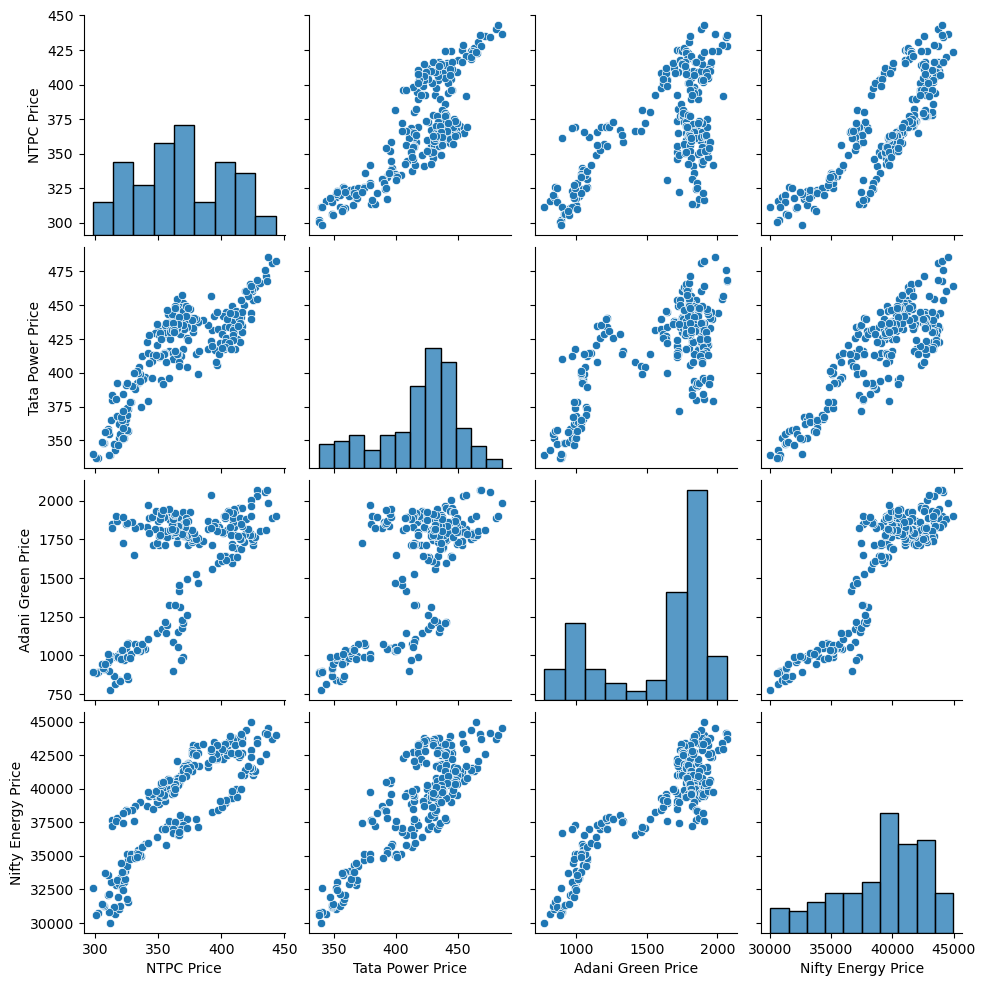

In [9]:
# Scatter plot 
sns.pairplot(df[['NTPC Price', 'Tata Power Price', 'Adani Green Price', 'Nifty Energy Price']])
plt.show()

In [10]:
#Interpretation
#This code creates a pair plot to show the correlations between the Nifty Energy index and the prices of NTPC, TATA POWER, and ADANI GREEN.  By displaying how these variables move in tandem, the scatter plots aid in identifying correlations; for example, company pricing may trend similarly to the Nifty Energy.  Price distributions for every stock are displayed by histograms.

In [11]:
# converting prices into LOG returns
df["Nifty Energy Price_r"]=np.log(df["Nifty Energy Price"]/df["Nifty Energy Price"].shift(1))
df["NTPC Price_r"]=np.log(df["NTPC Price"]/df["NTPC Price"].shift(1))
df["Tata Power Price_r"]=np.log(df["Tata Power Price"]/df["Tata Power Price"].shift(1))
df["Adani Green Price_r"]=np.log(df["Adani Green Price"]/df["Adani Green Price"].shift(1))
df.head()

,Date,Nifty Energy Price,NTPC Price,Tata Power Price,Adani Green Price,Nifty Energy Price_r,NTPC Price_r,Tata Power Price_r,Adani Green Price_r
0,02/28/2025,30018.15,311.45,339.2,774.40,NaN,NaN,NaN,NaN
1,02/27/2025,30659.25,315.70,343.3,811.75,0.021132,0.013554,0.012015,0.047104
2,02/25/2025,31018.30,318.70,351.5,840.65,0.011643,0.009458,0.023605,0.034983
3,02/24/2025,31240.80,320.10,354.6,836.05,0.007148,0.004383,0.008781,-0.005487
4,02/21/2025,31592.00,326.25,357.2,849.35,0.011179,0.019031,0.007305,0.015783


In [12]:
df.dropna(inplace=True)

In [13]:
df.head()

,Date,Nifty Energy Price,NTPC Price,Tata Power Price,Adani Green Price,Nifty Energy Price_r,NTPC Price_r,Tata Power Price_r,Adani Green Price_r
1,02/27/2025,30659.25,315.70,343.30,811.75,0.021132,0.013554,0.012015,0.047104
2,02/25/2025,31018.30,318.70,351.50,840.65,0.011643,0.009458,0.023605,0.034983
3,02/24/2025,31240.80,320.10,354.60,836.05,0.007148,0.004383,0.008781,-0.005487
4,02/21/2025,31592.00,326.25,357.20,849.35,0.011179,0.019031,0.007305,0.015783
5,02/20/2025,31769.65,325.15,357.95,864.95,0.005608,-0.003377,0.002097,0.018200


In [14]:
# check stationarity using ADF test
def check_stationarity(series,name):
    result=adfuller(series)
    print(f"\n{name}ADF test Results:")
    print(f"test Statistic:{result[0]:.4f}")
    print(f"P-value:{result[1]:.4f}")
    if result[1]>0.05:
        print(f"{name}is not stationarity")
    else:
        print(f"{name}is stationarity")

In [15]:
check_stationarity(df["Nifty Energy Price_r"],"Nifty Energy Price_r")
check_stationarity(df["NTPC Price_r"],"NTPC Price_r")
check_stationarity(df["Tata Power Price_r"],"Tata Power Price_r")
check_stationarity(df["Adani Green Price_r"],"Adani Green Price_r")


Nifty Energy Price_rADF test Results:
test Statistic:-18.3102
P-value:0.0000
Nifty Energy Price_ris stationarity

NTPC Price_rADF test Results:
test Statistic:-18.2701
P-value:0.0000
NTPC Price_ris stationarity

Tata Power Price_rADF test Results:
test Statistic:-16.5352
P-value:0.0000
Tata Power Price_ris stationarity

Adani Green Price_rADF test Results:
test Statistic:-8.2243
P-value:0.0000
Adani Green Price_ris stationarity


In [16]:
# y = Xa+b
#defining x and y variables 
Y=df["Nifty Energy Price_r"]
X=df["NTPC Price_r"]
Z=df["Tata Power Price_r"]
A=df["Adani Green Price_r"]

In [17]:
# constant
X=sm.add_constant(X)

In [18]:
model=sm.OLS(Y,X).fit()
print("\n OLS regression results",model.summary())


 OLS regression results                              OLS Regression Results                             
Dep. Variable:     Nifty Energy Price_r   R-squared:                       0.737
Model:                              OLS   Adj. R-squared:                  0.736
Method:                   Least Squares   F-statistic:                     688.1
Date:                  Tue, 18 Mar 2025   Prob (F-statistic):           4.24e-73
Time:                          10:06:52   Log-Likelihood:                 837.74
No. Observations:                   247   AIC:                            -1671.
Df Residuals:                       245   BIC:                            -1664.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
con

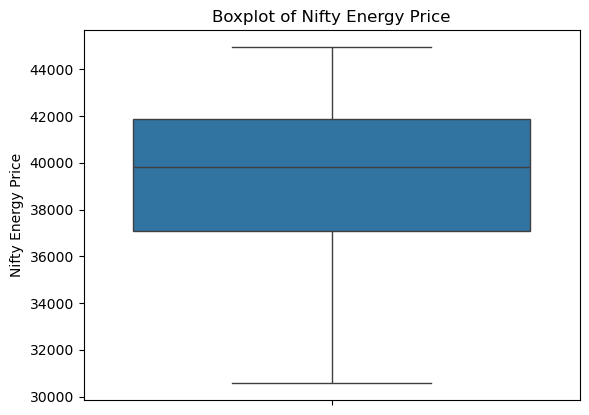

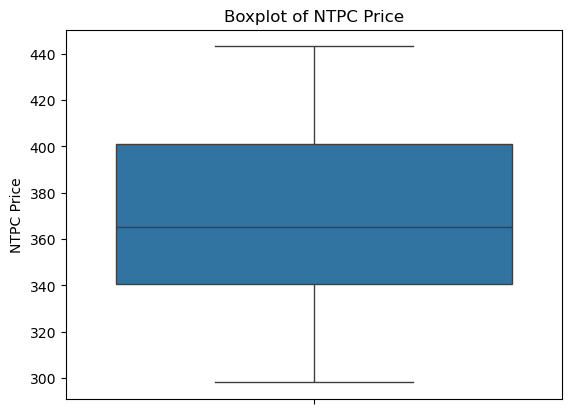

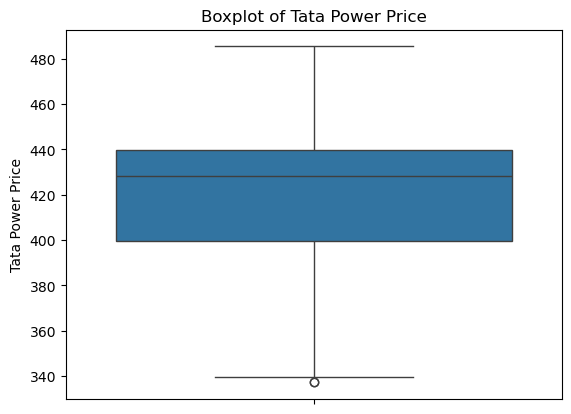

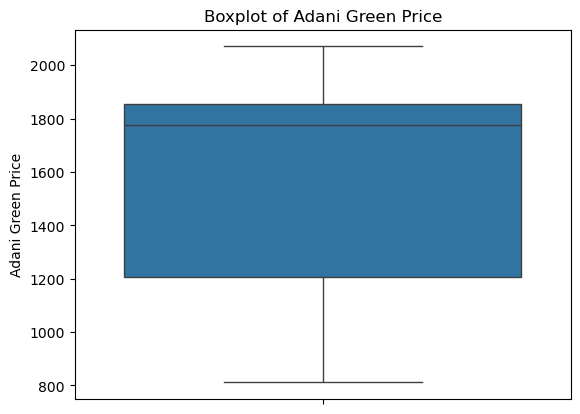

In [19]:
numeric_coloumn=["Nifty Energy Price","NTPC Price","Tata Power Price","Adani Green Price"]
for col in numeric_coloumn:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
#Interpretation
#The stock price distribution is shown visually by the boxplots for the Nifty 50, HDFC Bank, ICICI Bank, and SBI Bank prices, which show volatility or stability.  Stability is indicated by a narrow interquartile range (IQR), whereas price fluctuations are suggested by a wide IQR.  Outliers point to extreme price swings, often owing to significant events or market reactions.  In order to gauge the overall mood of the market, the median represents the average stock price level.  All things considered, the boxplots shed light on risk, pricing stability, and other areas that need more research or focus.

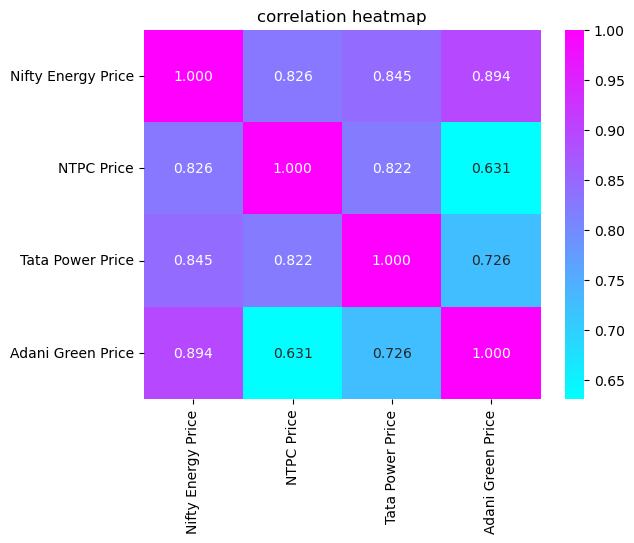

In [21]:
#correlation heatmap
numeric_coloumn=["Nifty Energy Price","NTPC Price","Tata Power Price","Adani Green Price"]
correlation=df[numeric_coloumn].corr()
sns.heatmap(correlation,annot=True,cmap="cool",fmt=".3f")
plt.title("correlation heatmap")
plt.show()

In [22]:
# Interpretation  

#Nifty Energy Price & NTPC Price (0.826): A strong positive correlation suggests that NTPC’s stock price moves in tandem with the Nifty Energy index, likely due to sector-wide influences and market trends.  

#Nifty Energy Price & Tata Power Price (0.845): This strong correlation indicates that Tata Power's stock price follows the broader energy sector movements, reflecting the overall market sentiment in the industry.  

#Nifty Energy Price & Adani Green Price (0.894): A very strong positive correlation implies that Adani Green's stock price is closely aligned with Nifty Energy, likely influenced by sectoral trends and investor sentiment toward renewable energy stocks.  

#NTPC Price & Tata Power Price (0.822): A strong correlation between NTPC and Tata Power suggests that both companies respond to similar market factors, such as changes in energy demand, government policies, or industry trends.  

#NTPC Price & Adani Green Price (0.631): A moderate correlation indicates that while NTPC and Adani Green share some common industry factors, their price movements may differ due to variations in business models, market positioning, or renewable energy-specific influences.  

#Tata Power Price & Adani Green Price (0.726): A moderately strong correlation suggests that both companies are impacted by trends in the energy sector, though Adani Green’s focus on renewable energy may lead to some independent price movements.

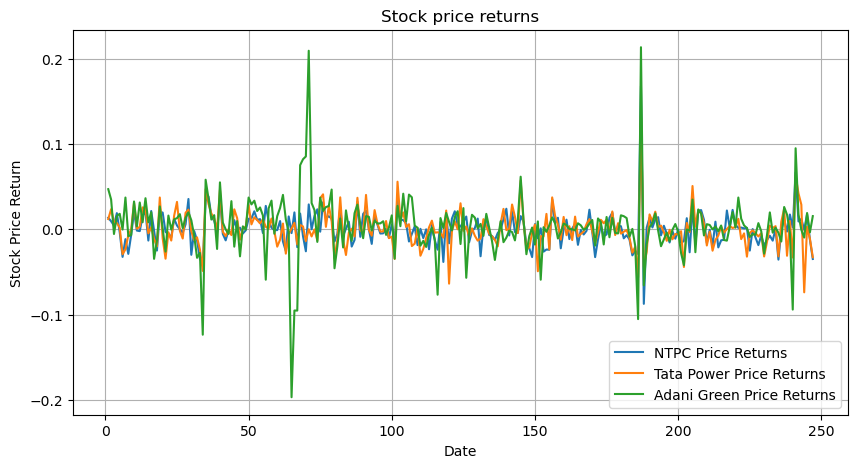

In [51]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["NTPC Price_r"], label="NTPC Price Returns")
plt.plot(df.index, df["Tata Power Price_r"], label="Tata Power Price Returns")
plt.plot(df.index, df["Adani Green Price_r"], label="Adani Green Price Returns")
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Price Return')
plt.title('Stock price returns')
plt.grid()
plt.show()